## K-Means (Unsupervised Learning)

Dado um conjunto de observações

$$
X = \{\vec{x_{i}}\}_{i=1}^{n}
$$
    
onde

$$
\vec{x_i} =
\begin{bmatrix}
  x_{i1} \\ x_{i2} \\ \vdots \\ x_{id}
  \end{bmatrix} \in \mathbb{R^{d}}
$$

Nosso objetivo é, dado um $k \leq n$, dividir $X$ em $k$ subconjuntos, ou seja

$$
S = \{S_{i}\}_{i=1}^{k}
$$

tal que

*   $S_{i} \neq \emptyset$
*   $S_{i} \cap S_{j} = \emptyset \quad \forall i \neq j$
*   $\displaystyle\bigcup_{i = 1}^{k} S_{i} = X$

Dessa forma, para $t = \{1, 2, 3, \cdots\}$, vamos construir $S_{i}^{(t)}$ da seguinte forma:

$$
S_{i}^{(t)} = \{x \in X : \lVert x - \mu_{i}^{(t)} \rVert^{2} \leq \lVert x - \mu_{j}^{(t)} \rVert^{2} \quad \forall j \neq i \}
$$

onde os centróides são dados por

$$
\mu_{i}^{(t+1)} = \dfrac{1}{|S_{i}^{(t)}|} \cdot \sum_{x \in S_{i}^{(t)}} x
$$

e os valores de $\mu_{i}^{(0)}$ podem ser dados pelo *Forgy Method:*

$$
\{\mu_{i}^{(0)}\}_{i = 1}^{k} \subset X
$$

O algoritmo é repetido até que ocorra a estabilização dos *clusters:*

$$
S_{i}^{(t+1)} = S_{i}^{(t)}  \quad \forall i \leq k
$$

## Aplicação Básica do K-Means Clustering

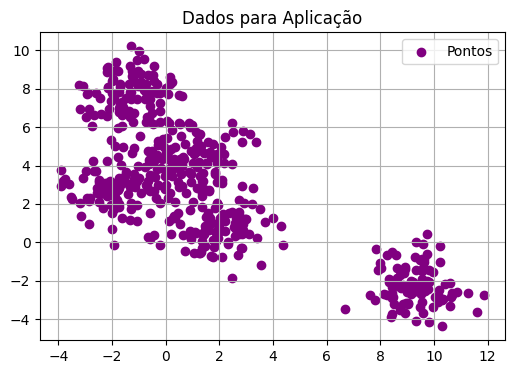

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from random import sample

X = np.loadtxt(
    "data.csv",
    delimiter=",",
    skiprows=1
)

plt.figure(figsize=(6,4))
plt.scatter(X[:, 0], X[:, 1], color='purple', label='Pontos')
plt.title("Dados para Aplicação")
plt.grid(True)
plt.legend()
plt.show()

### Funções auxiliares para o K-Means

In [2]:
def squaredEuclidean(x, u):
    return np.linalg.norm(x - u) ** 2

def forgyMethod(X, k):
  indices = np.random.choice(len(X), size=k, replace=False)
  return np.array(X)[indices]

def recalculateCentroids(S, k):
    newCentroids = []

    for i in range(k):
        cluster = np.array(S[i])
        mean = np.mean(cluster, axis=0)
        newCentroids.append(mean)

    return np.array(newCentroids)

def assignClusters(X, centroids):
  k = len(centroids)
  S = [[] for _ in range(k)]

  for x in X:
      distances = [squaredEuclidean(x, u) for u in centroids]
      i = np.argmin(distances)
      S[i].append(x)

  return S

def convergence(S, newS):
    return all(
        np.array_equal(np.array(S[i]), np.array(newS[i]))
        for i in range(len(S))
    )

### Implementação do K-Means

In [3]:
def kMeans(X, k, max_iters=100):

    c0 = forgyMethod(X, k)

    S = None

    for _ in range(max_iters):
        newS = assignClusters(X, c0)

        if S is not None and convergence(S, newS):
            break

        S = newS
        centroids = recalculateCentroids(S, k)

    return c0, centroids, S

### Mostrando os Centróides iniciais ($\mu_{i}^{(0)}$)

In [4]:
k = 4
c0, centroids, clusters = kMeans(X, k)

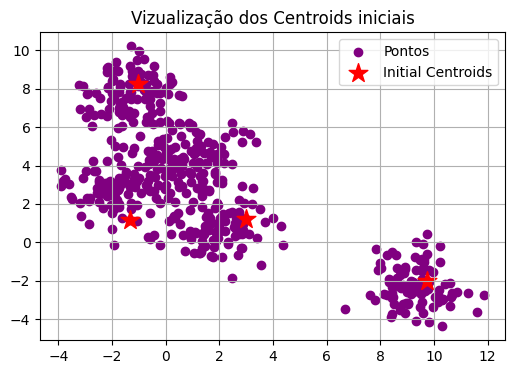

In [6]:
plt.figure(figsize=(6,4))
plt.scatter(X[:, 0], X[:, 1], color='purple', label='Pontos')
plt.scatter(c0[:, 0], c0[:, 1], marker='*', c='red', s=200, label='Initial Centroids')
plt.title("Vizualização dos Centroids iniciais")
plt.grid(True)
plt.legend()
plt.show()

### Mostrando resultado do K-Means Clustering

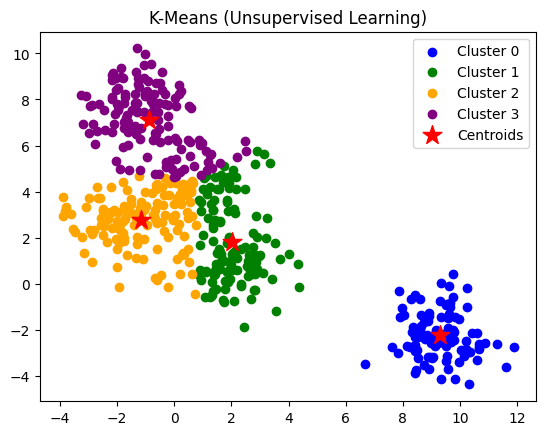

In [7]:
colors = ['blue', 'green', 'orange', 'purple']

for i, cluster in enumerate(clusters):
    cluster = np.array(cluster)
    plt.scatter(
        cluster[:, 0],
        cluster[:, 1],
        label=f'Cluster {i}',
        c=colors[i]
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker='*',
    s=200,
    c='red',
    label='Centroids'
)

plt.legend()
plt.title('K-Means (Unsupervised Learning)')
plt.show()